# Машинное обучение, ФКН ВШЭ #

## Практическое задание 5. Решающие деревья ##

### Общая информация ###

Дата выдачи: 16.04.2026

Мягкий дедлайн: 30.04.2026 23:59

Жесткий дедлайн:  05.05.2026 23:59

### О задании

В процессе выполнения этого домашнего задания вы:

1. Попрактикуетесь использовать решающие деревья из `sklearn` для задачи классификации на простых двумерных датасетах, научитесь визуализировать разделяющие плоскости и распознавать переобучение.

2. Реализуете своё решающее дерево для задачи классификации и сравните его со стандартной имплементацией.

3. Исследуете влияние бэггинга на смещение и разброс.

### Оценивание и штрафы

Каждая из задач имеет определенную стоимость, которая указана в скобках около номера задачи. Максимально допустимая оценка за работу $-$ 10 баллов.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.


### Формат сдачи

Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-05-trees-Username.ipynb
* Модуль hw5code.py
* Номера лучших посылок в Яндекс.Контесте для обеих задач

В **ССЫЛКА НА КОНТЕСТ** нужно отправить файл hw5code.py с реализованными функциями и классами.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__ 10 :)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

## Решающие деревья

### Визуализация (1 балл)

Рассмотрим три простых двумерных датасета, сгенерированных с помощью `make_moons`, `make_circles` и `make_classification`.

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                        class_sep=0.75, random_state=3, n_redundant=0)
]

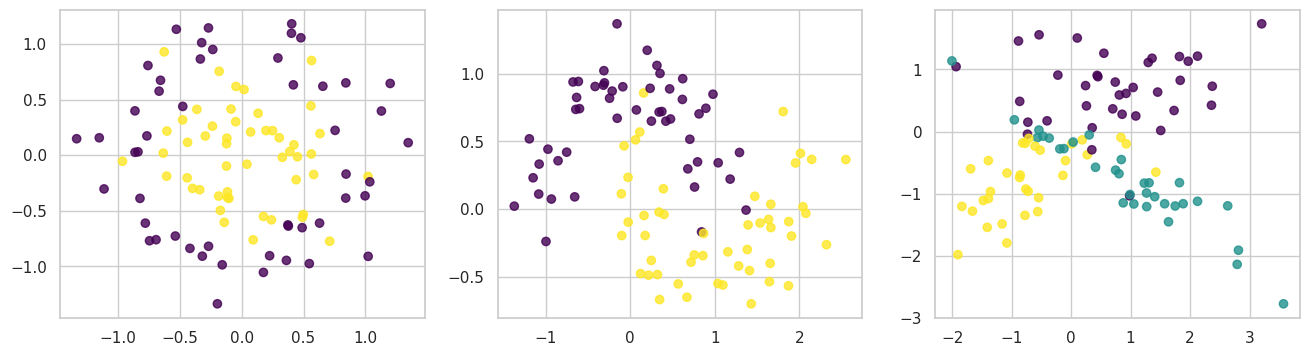

In [ ]:
plt.figure(figsize=(16, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.8)

__Задание 1. (0.5 балла)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности и посчитайте accuracy на обучающей и тестовой выборках. Прокомментируйте, в каких случаях и почему модель переобучается.

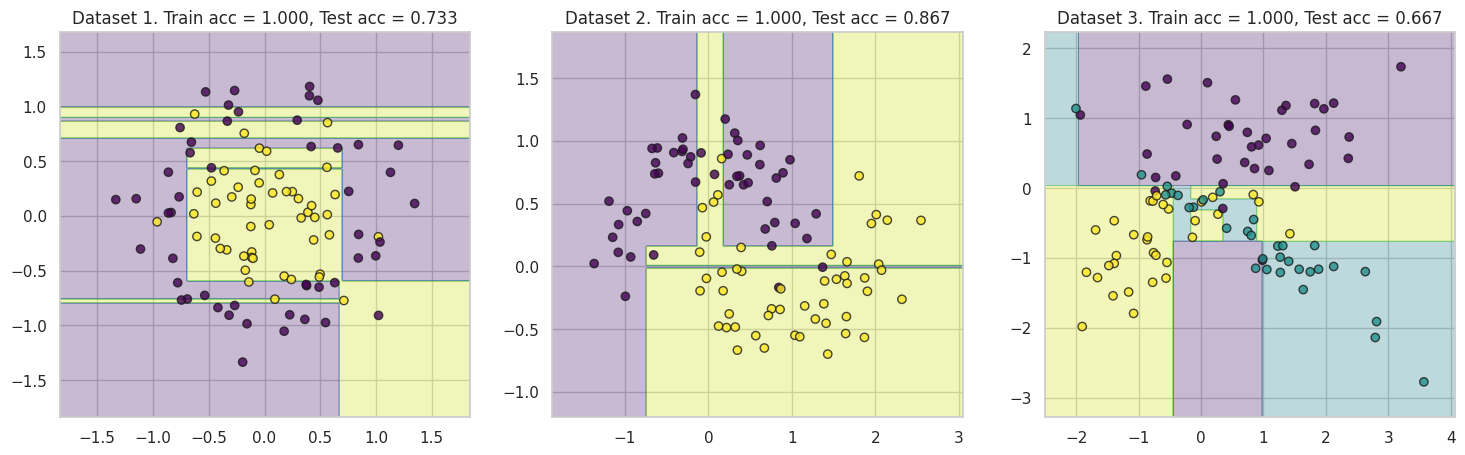

[(1.0, 0.7333333333333333),
 (1.0, 0.8666666666666667),
 (1.0, 0.6666666666666666)]

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
def plot(clf, X, y, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", alpha=0.8)

plt.figure(figsize=(18, 5))
results = []

for i, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    results.append((train_acc, test_acc))

    ax = plt.subplot(1, 3, i + 1)
    plot(clf, X, y, ax)
    ax.set_title(f"Dataset {i+1}. Train acc = {train_acc:.3f}, Test acc = {test_acc:.3f}")

plt.show()
results

__Ответ:__ Во всех трёх датасетах дерево без ограничений глубины даёт train accuracy = 1.0, потому что оно полностью запоминает обучающие точки \
Dataset 1: \
Test acc = 0.733. Заметное переобучение. Дерево строит много мелких прямоугольных областей, пытаясь подогнаться под шум. \
Dataset 2:  
Test acc = 0.867. Переобучение слабее, так как классы разделены лучше, шум ниже.\
Dataset 3:  
Test acc = 0.667. Самое сильное переобучение. Много классов, шум, пересечения - дерево рвет пространство на мелкие куски.
Дерево переобучается, когда структура сложная или шумная, потому что без ограничений глубины оно запоминает данные вместо обобщения.

__Задание 2. (0.5 балла)__

Выберите один датасет из предыдущего задания и исследуйте на его примере влияние на итоговое качество двух гиперпараметров (любых на ваш выбор) одновременно. Для каждой пары значений посчитайте accuracy на обучающей и тестовой выборках и сохраните результаты в таблицу.

Визуализируйте зависимость качества на тестовой выборке от значений выбранных вами гиперпараметров. При каких значениях наблюдается лучшее соотношение разброса и смещения? Почему вы сделали такой вывод?

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
# выберем датасет 2
X, y = datasets[1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
max_depth_values = [1, 2, 3, 4, 5, None]
min_samples_leaf_values = [1, 2, 4, 6, 8]
results = []
for depth in max_depth_values:
    for leaf in min_samples_leaf_values:
        clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf, random_state=42)
        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        test_acc = clf.score(X_test, y_test)

        results.append({"max_depth": depth, "min_samples_leaf": leaf, "train_acc": train_acc, "test_acc": test_acc})

df_results = pd.DataFrame(results)
df_results

,max_depth,min_samples_leaf,train_acc,test_acc
0,1.0,1,0.842857,0.800000
1,1.0,2,0.842857,0.800000
2,1.0,4,0.842857,0.800000
3,1.0,6,0.842857,0.800000
4,1.0,8,0.842857,0.800000
5,2.0,1,0.914286,0.933333
6,2.0,2,0.900000,0.833333
7,2.0,4,0.900000,0.833333
8,2.0,6,0.871429,0.766667
9,2.0,8,0.842857,0.800000


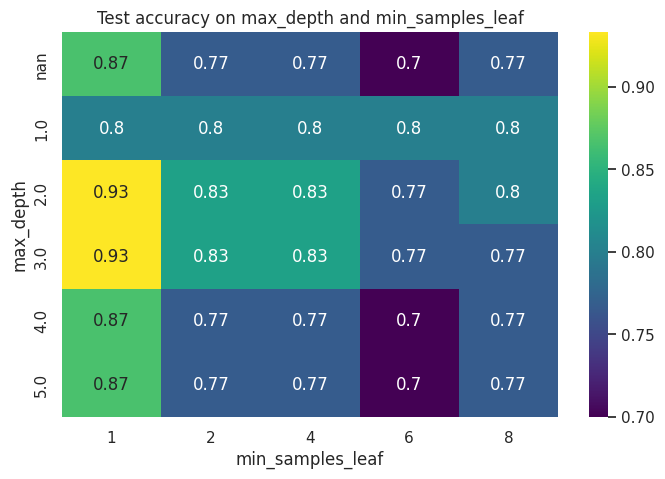

In [ ]:
pivot = df_results.pivot(index="max_depth", columns="min_samples_leaf", values="test_acc")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Test accuracy on max_depth and min_samples_leaf")
plt.show()

__Ответ:__ лучшее соотношение смещения и разброса наблюдается при max_depth = 2–3 и min_samples_leaf = 1: тестовая accuracy достигает 0.93, при этом train accuracy остаётся < 1, то есть модель не переобучается полностью.
При меньшей глубине модель недообучена -> низкое качество.  
При большей глубине или больших min_samples_leaf модель начинает переобучаться или теряет гибкость.

### Решающие деревья своими руками (6 баллов)

Итак, пришло время реализовать свой класс для обучения решающего дерева.

__Задание 3. (1.5 балла)__

Реализуйте функцию `find_best_split` из модуля `hw5code.py` согласно алгоритму, расказанному на лекции; её сигнатура и докстринг с дополнительными требованиями и указаниями прописаны в файле.

Напоминаем, что под критерием Джини подразумевается следующая функция качества разбиения:

$$
Q(R, R_l, R_r) = -\frac{|R_l|}{|R|} H(R_l) - \frac{|R_r|}{|R|} H(R_r),
$$

где $R$ - множество объектов, $R_l$ и $R_r$ - объекты, попавшие в левое и правое поддерево соответственно.

Функция неоднородности Джини для множества $R$ определяется как

$$
H(R) = 1 - \sum_{k=1}^{K} p_k^2,
$$

где $p_k$ - доля объектов класса $k$ в множестве $R$, а $K$ - число различных классов в текущем узле.

Замечание: при $K=2$ формула сводится к бинарному случаю $H(R)=1-p_0^2-p_1^2$, где $p_1$ и $p_0$ $-$ доля объектов классов $1$ и $0$ соответственно.


In [ ]:
import numpy as np
from collections import Counter


def find_best_split(feature_vector, target_vector):
    order = np.argsort(feature_vector)
    x = feature_vector[order]
    y = target_vector[order]
    unique_vals = np.unique(x)
    if len(unique_vals) == 1:
        return np.array([]), np.array([]), None, None
    thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2
    idx = np.searchsorted(x, thresholds, side='left')
    n = len(x)
    classes, y_enc = np.unique(y, return_inverse=True)
    K = len(classes)
    cum = np.zeros((n + 1, K), dtype=float)
    cum[1:] = np.eye(K)[y_enc].cumsum(axis=0)
    left_counts = cum[idx]
    total_counts = cum[-1]
    right_counts = total_counts - left_counts
    n_left = left_counts.sum(axis=1)
    n_right = n - n_left
    mask = (n_left > 0) & (n_right > 0)
    if not mask.any():
        return np.array([]), np.array([]), None, None
    thresholds = thresholds[mask]
    left_counts = left_counts[mask]
    right_counts = right_counts[mask]
    n_left = n_left[mask]
    n_right = n_right[mask]
    p_left = left_counts / n_left[:, None]
    p_right = right_counts / n_right[:, None]
    H_left = 1 - (p_left ** 2).sum(axis=1)
    H_right = 1 - (p_right ** 2).sum(axis=1)
    ginis = -(n_left / n) * H_left - (n_right / n) * H_right
    best_idx = np.argmax(ginis)
    threshold_best = thresholds[best_idx]
    gini_best = ginis[best_idx]
    return thresholds, ginis, threshold_best, gini_best

class DecisionTree:

    def __init__(self, feature_types, max_depth=None, min_samples_split=None, min_samples_leaf=None):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")
        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf

    def _fit_node(self, sub_X, sub_y, node, depth=0):
        if len(np.unique(sub_y)) == 1:
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        if self._max_depth is not None and depth >= self._max_depth:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        if self._min_samples_split is not None and len(sub_y) < self._min_samples_split:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        feature_best, threshold_best, gini_best, best_split_mask = None, None, None, None

        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]

            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            else:
                feature_col = sub_X[:, feature]
                categories = np.unique(feature_col)
                means = {cat: np.mean(sub_y[feature_col == cat]) for cat in categories}
                sorted_cats = sorted(categories, key=lambda c: means[c])
                cat_to_int = {cat: i for i, cat in enumerate(sorted_cats)}
                feature_vector = np.array([cat_to_int[z] for z in feature_col])

            thresholds, ginis, thr, gini = find_best_split(feature_vector, sub_y)

            if thresholds is None or len(thresholds) == 0:
                continue

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini
                threshold_best = thr
                best_split_mask = feature_vector < thr

        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best

        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        else:
            feature_col = sub_X[:, feature_best]
            categories = np.unique(feature_col)
            means = {cat: np.mean(sub_y[feature_col == cat]) for cat in categories}
            sorted_cats = sorted(categories, key=lambda c: means[c])
            cat_to_int = {cat: i for i, cat in enumerate(sorted_cats)}
            node["categories_split"] = [cat for cat in categories if cat_to_int[cat] < threshold_best]

        left_mask = best_split_mask
        right_mask = ~best_split_mask

        if self._min_samples_leaf is not None:
            if left_mask.sum() < self._min_samples_leaf or right_mask.sum() < self._min_samples_leaf:
                node["type"] = "terminal"
                node["class"] = Counter(sub_y).most_common(1)[0][0]
                return

        node["left_child"], node["right_child"] = {}, {}

        self._fit_node(sub_X[left_mask], sub_y[left_mask], node["left_child"], depth + 1)
        self._fit_node(sub_X[right_mask], sub_y[right_mask], node["right_child"], depth + 1)

    def _predict_node(self, x, node):
        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]
        if self._feature_types[feature] == "real":
            thr = node["threshold"]
            if x[feature] < thr:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        elif self._feature_types[feature] == "categorical":
            if x[feature] in node["categories_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        else:
            raise ValueError

    def fit(self, X, y):
        self._fit_node(X, y, self._tree)

    def predict(self, X):
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

class LinearRegressionTree():
    def __init__(self, feature_types, base_model_type=None, max_depth=None, min_samples_split=None, min_samples_leaf=None):
        pass


__Задание 4. (0.75 балл)__

Загрузите датасет [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance). Поработайте с данными: создайте бинарный признак `pass`, который будет равен единице, если итоговая оценка `G3` не меньше $10$, и нулю в противном случае. Затем выберите пять числовых признаков, среди которых должны быть как очень информативные, так и потенциально неинформативные. Коротко обоснуйте свой выбор.

Для каждого из выбранных признаков постройте график зависимости критерия Джини от возможного порога разделения. Отобразите все пять кривых на одном рисунке.

Для каждого из выбранных признаков дополнительно визуализируйте зависимость
"значение признака - класс (0/1)".

> Можно, например, построить scatter-график, где по оси X - значение признака, а по оси Y - бинарный признак `pass` (при необходимости используйте небольшой jitter по оси Y и/или прозрачность alpha, чтобы лучше видеть плотность точек); или использовать эквивалентную по смыслу визуализацию (например, `seaborn.stripplot` / `swarmplot`), из которой видно, как распределены значения признака внутри каждого класса.

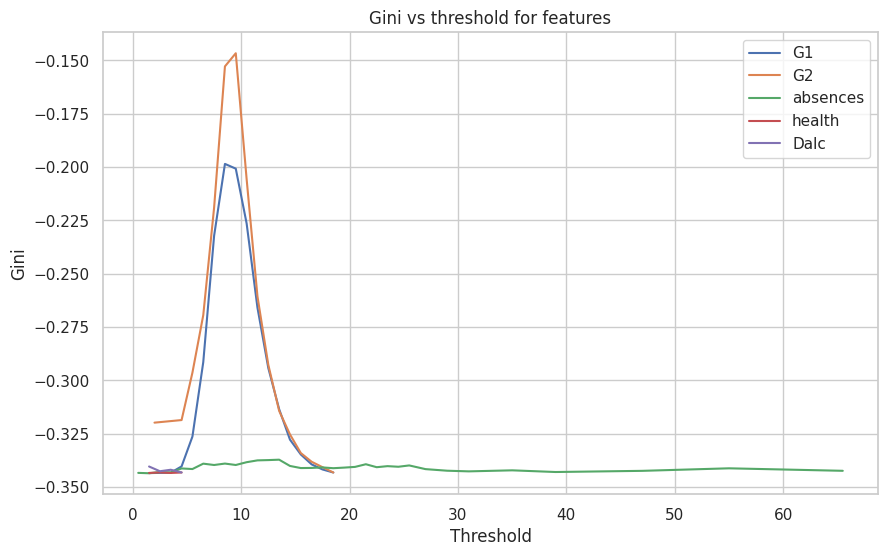

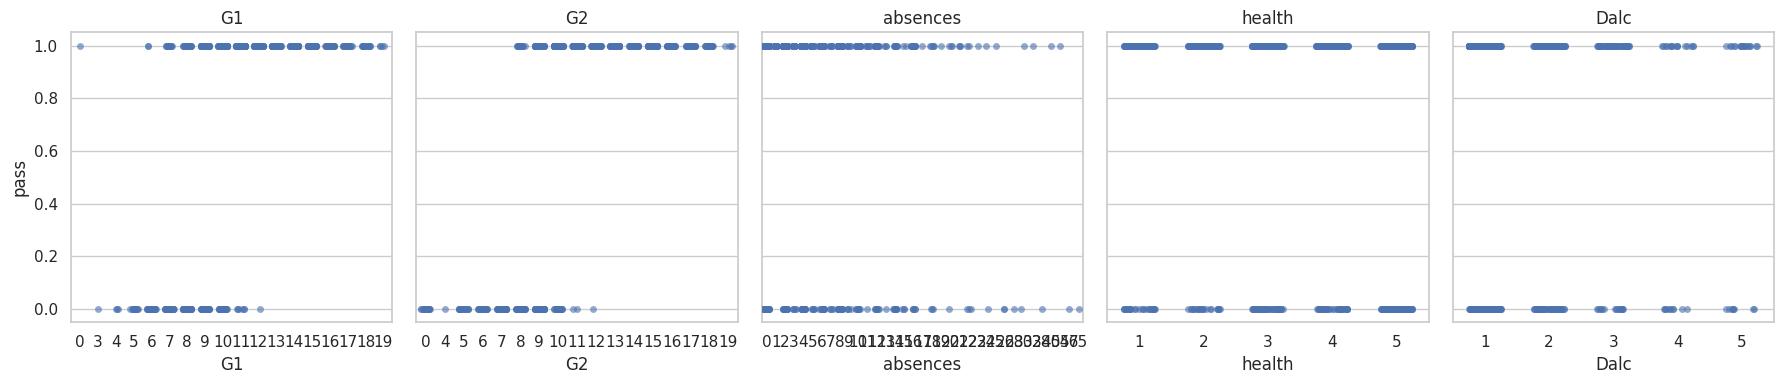

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
mat_path = "/kaggle/input/datasets/juli06/student-perfomance/student/student-mat.csv"
por_path = "/kaggle/input/datasets/juli06/student-perfomance/student/student-por.csv"

mat = pd.read_csv(mat_path, sep=";")
por = pd.read_csv(por_path, sep=";")
df = pd.concat([mat, por], ignore_index=True)

df["pass"] = (df["G3"] >= 10).astype(int)
features = ["G1", "G2", "absences", "health", "Dalc"]

plt.figure(figsize=(10, 6))
for feat in features:
    x = df[feat].values
    y = df["pass"].values
    thresholds, ginis, thr_best, gini_best = find_best_split(x, y)
    if len(thresholds) > 0:
        plt.plot(thresholds, ginis, label=feat)

plt.xlabel("Threshold")
plt.ylabel("Gini")
plt.title("Gini vs threshold for features")
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for i, feat in enumerate(features):
    sns.stripplot(x=df[feat], y=df["pass"], jitter=0.25, alpha=0.6, ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_ylabel("pass" if i == 0 else "")

plt.tight_layout()
plt.show()

__Ответ:__
Для анализа выбраны признаки G1, G2, absences, health, Dalc.  \
G1 и G2 информативны, так как являются предыдущими оценками и напрямую связаны с итоговой.   
Absences, health и Dalc потенциально слабее: они отражают поведение и состояние ученика, но не обязательно определяют факт сдачи.
На графике Gini видно, что: G1 и G2 дают самые высокие значения критерия, то есть лучше всего разделяют классы; absences, health, Dalc имеют почти плоские кривые, значит, они плохо разделяют pass/fail. Scatter-графики подтверждают: G1 и G2 чётко отделяют успевающих от неуспевающих, тогда как absences, health и Dalc распределены почти одинаково для обоих классов.

__Задание 5. (0.25 балла)__

На основании построенных в прошлом задании графиков ответьте на следующие вопросы:

1. По какому признаку нужно производить деление выборки на два поддерева? Почему?

2. Согласуется ли этот результат с тем, что видно на scatter-графиках? Совпадают ли выводы?

3. Как выглядят кривые для тех признаков, по которым классы разделяются почти идеально? Чем отличаются от них кривые для признаков, по которым деление практически невозможно?

**Ответ:**
1. Делить выборку нужно по признаку G2 (вторая оценка): его кривая Gini достигает наибольшего значения, то есть он даёт наибольший прирост качества при разбиении.

2. Да, результат согласуется со scatter-графиками: по G2 (и чуть хуже по G1) классы 0/1 хорошо отделяются порогом около 10, тогда как по absences, health, Dalc точки двух классов сильно перемешаны.

3. Для признаков с почти идеальным разделением (G1, G2) кривая Gini имеет выраженный пик в окрестности оптимального порога и заметно отличается от базового уровня. Для слабоинформативных признаков (absences, health, Dalc) кривые почти плоские и лежат около одного значения, то есть качество почти не меняется при изменении порога.

__Задание 6. (1.5 балла)__

Разберитесь с уже написанным кодом в классе `DecisionTree` модуля `hw5code.py`. Исправьте ошибки в методе `_fit_node`, а также реализуйте `_predict_node`.

В данном задании:
* построение дерева осуществляется согласно базовому жадному алгоритму, предложенному на лекции
* выбор лучшего разбиения необходимо производить по критерию Джини
* в качестве критерия останова используется следующий: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку
* ответ в листе $-$ это наиболее часто встречающийся в нём класс
* для категориальных признаков выполняется преобразование, описанное на лекции (можете найти его в конспекте в разделе «Учёт категориальных признаков»)

__Задание 7. (0.5 балла)__

Протестируйте написанное вами решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Для этого необходимо скачать таблицу agaricus-lepiota.data и применить к каждому столбцу LabelEncoder, чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец в рассматриваемой таблице $-$ это целевая переменная ('e' $-$ edible, 'p' $-$ poisonous).

Обучите решающее дерево на $50\%$ случайно выбранных объектов и получите предсказания для оставшейся половины. Вычислите accuracy. Если в предыдущих заданиях вы всё сделали корректно, то у вас должно получиться качество очень близкое единице или даже равное ей.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
data_path = "/kaggle/input/datasets/juli06/mushroom/agaricus-lepiota.data"
cols = [
    "target", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color", "ring-number",
    "ring-type", "spore-print-color", "population", "habitat"
]
df = pd.read_csv(data_path, header=None)
df.columns = cols
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
X = df.drop("target", axis=1).values
y = df["target"].values
feature_types = ["categorical"] * X.shape[1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, shuffle=True
)
tree = DecisionTree(feature_types=feature_types)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
accuracy = (y_pred == y_test).mean()
accuracy

np.float64(1.0)

__Задание 8. (1 балл)__

Реализуйте в классе `DecisionTree` поддержку параметров `max_depth`, `min_samples_split` и `min_samples_leaf` по аналогии с `sklearn.tree.DecisionTreeClassifier`.

__Задание 9. (0.5 балла)__

Проверьте, спасают эти параметры вас от переобучения.

Для этого **решите при помощи собственной имплементации `DecisionTree`  задачу классификации цвета вина** (color) по его химическим характеристикам на датасете [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality).

Как обычно, случайно разбейте свой датасет на тест-трейн (в отношении 7:3), и далее сравните на них поведение двух деревьев:
- Для первого дерева не используйте параметры из задания 8
- Для второго дерева выберите разумные значения этих параметров (в этом конкретном случае мы рекомендуем `max_depth=8, min_samples_leaf=5, min_samples_split=17`), и постройте дерево с их использованием.
  - Подбирать оптимальные параметры здесь не требуется

Выведите метрики качества классификации. **Что вы наблюдаете, и почему так произошло?**


В качестве sanity check сравните качество работы и структуру вашего второго дерева с результатом стандартной имплементации из `sklearn`. Не забудьте подать ему на вход те же параметры.

**Обратите внимание, что в оригинале таргетом является качество вина; мы же с вами предсказываем его цвет.** В каком-то смысле, это модель-сомелье.


*Андер-сэмплирование данных далее сделано специально, чтобы продемонстрировать должный эффект. Убирать его запрещается.*

In [ ]:
!pip install -U ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

np.random.seed(0)

wine_quality = fetch_ucirepo(id=186)


In [ ]:

df = wine_quality.data.original.sample(frac=0.1)

X = df.drop(columns=['color'])
y = df['color']


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 650 entries, 5773 to 406
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         650 non-null    float64
 1   volatile_acidity      650 non-null    float64
 2   citric_acid           650 non-null    float64
 3   residual_sugar        650 non-null    float64
 4   chlorides             650 non-null    float64
 5   free_sulfur_dioxide   650 non-null    float64
 6   total_sulfur_dioxide  650 non-null    float64
 7   density               650 non-null    float64
 8   pH                    650 non-null    float64
 9   sulphates             650 non-null    float64
 10  alcohol               650 non-null    float64
 11  quality               650 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 66.0 KB


In [ ]:
y.info()

<class 'pandas.core.series.Series'>
Index: 650 entries, 5773 to 406
Series name: color
Non-Null Count  Dtype 
--------------  ----- 
650 non-null    object
dtypes: object(1)
memory usage: 10.2+ KB


In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
y_bin = (y == 'red').astype(int)
X_num = X.copy()
for col in X_num.columns:
    X_num[col] = pd.to_numeric(X_num[col], errors='coerce')
X_num = X_num.dropna()
y_bin = y_bin.loc[X_num.index]
X_train, X_test, y_train, y_test = train_test_split(
    X_num.values,
    y_bin.values,
    test_size=0.3,
    random_state=0,
    stratify=y_bin.values
)
feature_types = ["real"] * X_train.shape[1]
my_tree_unrestricted = DecisionTree(feature_types=feature_types)
my_tree_unrestricted.fit(X_train, y_train)
train_pred_unrestricted = my_tree_unrestricted.predict(X_train)
test_pred_unrestricted = my_tree_unrestricted.predict(X_test)
print("=== My tree: unrestricted ===")
print("Train accuracy:", accuracy_score(y_train, train_pred_unrestricted))
print("Test accuracy:", accuracy_score(y_test, test_pred_unrestricted))
print("Test classification report:")
print(classification_report(y_test, test_pred_unrestricted))
print("Test confusion matrix:")
print(confusion_matrix(y_test, test_pred_unrestricted))
print()
my_tree_regularized = DecisionTree(
    feature_types=feature_types,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=17
)
my_tree_regularized.fit(X_train, y_train)
train_pred_regularized = my_tree_regularized.predict(X_train)
test_pred_regularized = my_tree_regularized.predict(X_test)
print("=== My tree: regularized ===")
print("Train accuracy:", accuracy_score(y_train, train_pred_regularized))
print("Test accuracy:", accuracy_score(y_test, test_pred_regularized))
print("Test classification report:")
print(classification_report(y_test, test_pred_regularized))
print("Test confusion matrix:")
print(confusion_matrix(y_test, test_pred_regularized))
print()
sk_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=17,
    random_state=0
)
sk_tree.fit(X_train, y_train)
train_pred_sk = sk_tree.predict(X_train)
test_pred_sk = sk_tree.predict(X_test)
print("=== sklearn tree: regularized ===")
print("Train accuracy:", accuracy_score(y_train, train_pred_sk))
print("Test accuracy:", accuracy_score(y_test, test_pred_sk))
print("Test classification report:")
print(classification_report(y_test, test_pred_sk))
print("Test confusion matrix:")
print(confusion_matrix(y_test, test_pred_sk))
print()
print("My regularized tree structure:")
print(my_tree_regularized._tree)
print()
print("sklearn tree depth:", sk_tree.get_depth())
print("sklearn tree leaves:", sk_tree.get_n_leaves())

=== My tree: unrestricted ===
Train accuracy: 1.0
Test accuracy: 0.9692307692307692
Test classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       150
           1       0.98      0.89      0.93        45

    accuracy                           0.97       195
   macro avg       0.97      0.94      0.96       195
weighted avg       0.97      0.97      0.97       195

Test confusion matrix:
[[149   1]
 [  5  40]]

=== My tree: regularized ===
Train accuracy: 0.989010989010989
Test accuracy: 0.9692307692307692
Test classification report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       150
           1       0.93      0.93      0.93        45

    accuracy                           0.97       195
   macro avg       0.96      0.96      0.96       195
weighted avg       0.97      0.97      0.97       195

Test confusion matrix:
[[147   3]
 [  3  42]]

=== sklearn tre

In [ ]:
print(classification_report(
    y_test,
    test_pred_regularized,
    target_names=['white', 'red']
))

              precision    recall  f1-score   support

       white       0.98      0.98      0.98       150
         red       0.93      0.93      0.93        45

    accuracy                           0.97       195
   macro avg       0.96      0.96      0.96       195
weighted avg       0.97      0.97      0.97       195



## Bias-variance decomposition (3 балла)

В этой части задания воспользуемся возможностями бутстрапа для оценки смещения и разброса алгоритмов машинного обучения.

В этом разделе мы будем работать с датасетом `California housing` из `sklearn.datasets.fetch_california_housing`. Это задача регрессии: по признакам района (доход, возраст домов и т.п.) нужно предсказать MedHouseVal - медианная стоимость жилья.

In [ ]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X = california["data"]
y = california["target"]

X.shape, y.shape

((20640, 8), (20640,))

Во всех заданиях этого раздела (задания 10-11) используйте одни и те же данные `X, y` и три стандартные модели из sklearn:

* `LinearRegression`
* `DecisionTreeRegressor`
* `RandomForestRegressor`

Все три модели имеют единый интерфейс, что позволит передавать их в общие функции.


### Вычисление bias и variance (1.5 балл)

На [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/lecture-notes/lecture08-ensembles.pdf) была выведена следующая формула, показывающая, как можно представить ошибку алгоритма регрессии в виде суммы трех компонент:
$$
L(\mu) =
    \mathbb{E}_{x, y}\bigl[\mathbb{E}_{X}\bigl[ (y - \mu(X)(x))^2 \bigr]\bigr] =
$$

$$
    \underbrace{\mathbb{E}_{x, y}\bigl[(y - \mathbb{E}[y|x] )^2\bigr]}_{\text{шум}} + \underbrace{\mathbb{E}_{x}\bigl[(\mathbb{E}_{X}[\mu(X)(x)] - \mathbb{E}[y|x] )^2\bigr]}_{\text{смещение}} +
    \underbrace{\mathbb{E}_{x}\bigl[\mathbb{E}_{X}\bigl[(\mu(X)(x) - \mathbb{E}_{X}[\mu(X)(x)] )^2\bigr]\bigr]}_{\text{разброс}},
$$
* $\mu(X)$ — алгоритм, обученный по выборке $X = \{(x_1, y_1), \dots (x_\ell, y_\ell)\}$;
* $\mu(X)(x)$ — ответ алгоритма, обученного по выборке $X$, на объекте $x$;
* $\mathbb{E}_{X}$ — мат. ожидание по всем возможным выборкам;
* $\mathbb{E}_{X}[\mu(X)(x)]$ — "средний" ответ алгоритма, обученного по всем возможным выборкам $X$, на объекте $x$.
    
С помощью этой формулы мы можем анализировать свойства алгоритма обучения модели $\mu$, если зададим вероятностную модель порождения пар $p(x, y)$.

В реальных задачах мы, конечно же, не знаем распределение на парах объект - правильный ответ. Однако у нас есть набор семплов из этого распределения (обучающую выборка), и мы можем использовать его, чтобы оценивать математические ожидания. Для оценки мат. ожиданий по выборкам мы будем пользоваться бутстрэпом - методом генерации "новых" выборок из одной с помощью выбора объектов с возвращением. Разберем несколько шагов на пути к оценке смещения и разброса.

#### **Приближенное вычисление интегралов**

Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar z} f(\bar z)$ функции от многомерной случайной величины $\bar z = (z_1, \dots, z_d)$, $\bar z \sim p(\bar z)$, можно сгенерировать выборку из распределения $p(\bar z)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar z} f(z) = \int f(\bar z) p(\bar z) d \bar z \approx \frac 1 m \sum_{i=1}^m f(\bar z_i), \, \bar z_i \sim p(\bar z), i = 1, \dots, m.$$

Например, оценим $\mathbb{E}_z z^2,$ $z \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_z z^2 = \sigma^2 + \mu^2 = 34$):

In [ ]:
z = np.random.normal(loc=5, scale=3, size=1000)
(z**2).mean()

np.float64(32.42884240825921)

#### **Оценивание $\mathbb{E}_{x, y}$**

Оценить мат. ожидания по $x$ и по $x, y$, встречающиеся во всех трех компонентах разложения, несложно, потому что у нас есть выборка объектов из распределения данных $p(x, y)$:
$$ \mathbb{E}_{x} f(x) \approx \frac 1 N \sum_{i=1}^N f(x_i), \quad
\mathbb{E}_{x, y} f(x, y) \approx \frac 1 N \sum_{i=1}^N f(x_i, y_i),$$
где $N$ - число объектов в выборке, $\{(x_i, y_i)\}_{i=1}^N$ - сама выборка.

#### **Оценивание $\mathbb{E}_X$ с помощью бутстрапа**

Чтобы оценить мат. ожидание по $X$, нам понадобится выборка из выборок:
$$\mathbb{E}_X f(X) \approx \frac 1 s \sum_{j=1}^s f(X_j),$$
где $X_j$ - $j$-я выборка. Чтобы их получить, мы можем воспользоваться бутстрапом - методом генерации выборок на основе выбора объектов с возвращением. Чтобы составить одну выборку, будем $N$ раз выбирать индекс объекта $i \sim \text{Uniform}(1 \dots N)$ и добавлять $i$-ю пару (объект, целевая переменная) в выборку. В результате в каждой выборке могут появиться повторяющиеся объекты, а какие-то объекты могут вовсе не войти в некоторые выборки.

**Почему именно выбор с возвращением?**

В классическом бутстрапе мы считаем, что единственное, что у нас есть про распределение данных $p(x, y)$, - это эмпирическое распределение на нашей выборке: каждый объект имеет вероятность $1/N$. Тогда "новая" обучающая выборка размера $N$ моделируется как $N$ независимых выборов *с возвращением* из этого эмпирического распределения.

Отсюда появляются:
* повторы объектов в бутстрап-выборке,
* и, наоборот, out-of-bag объекты, которые в конкретную бутстрап-выборку не попали.

Повторы не являются ошибкой или "зашумлением" эксперимента - они как раз и отражают то, насколько алгоритм чувствителен к конкретным объектам (в том числе к выбросам). Если бы мы каждый раз просто брали подвыборки без возвращения, мы бы изучали уже немного другую процедуру (скорее subsampling / k-fold CV), а не классический бутстрап.

#### **Итоговый алгоритм оценки смещения и разброса алгоритма $a$**
1. Сгенерировать $s$ выборок $X_j$ методом бутстрапа.
1. На каждой выборке $X_j$ обучить алгоритм $a_j$.
1. Для каждой выборки $X_j$ определить множество объектов $T_j$, не вошедших в нее (out-of-bag). Вычислить предсказания алгоритма $a_j$ на объектах $T_j$.

Поскольку у нас есть только один ответ для каждого объекта, мы будем считать шум равным 0, а $\mathbb{E}[y|x]$ равным имеющемуся правильному ответу для объекта $x$.

Итоговые оценки:
* Смещение: для одного объекта - квадрат разности среднего предсказания и правильного ответа. Среднее предсказание берется только по тем алгоритмам $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего смещения выполнить усреденение смещений по объектам.
* Разброс: для одного объекта - выборочная дисперсия предсказаний алгоритмов $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего разброса выполнить усреденение разбросов по объектам.
* Ошибка $L$: усреднить квадраты разностей предсказания и правильного ответа по всем выполненным предсказаниям для всех объектов.

В результате должно получиться, что ошибка приблизительно равна сумме смещения и разброса!

Алгоритм также вкратце описан по [ссылке](https://web.engr.oregonstate.edu/~tgd/classes/534/slides/part9.pdf) (слайды 19-21).

__Задание 10.1 (1 балл)__

Реализуйте описанный алгоритм. Обратите внимание, что если объект не вошел ни в одну из out-of-bag выборок, учитывать его в вычислении итоговых величин не нужно. Как обычно, разрешается использовать только один цикл - по выборкам (от 0 до num_runs-1).

In [ ]:
def compute_biase_variance(model, X, y, num_runs=1000):

    """
    :param model: sklearn estimator with fit(...) and predict(...) method
    :param X: numpy-array representing training set ob objects, shape [n_obj, n_feat]
    :param y: numpy-array representing target for training objects, shape [n_obj]
    :param num_runs: int, number of samples (s in the description of the algorithm)

    :returns: bias (float), variance (float), error (float)
    each value is computed using bootstrap
    """

    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    n = len(X)
    preds_oob = [[] for _ in range(n)]

    for _ in range(num_runs):
        idx_boot = np.random.randint(0, n, size=n)
        mask = np.ones(n, dtype=bool)
        mask[idx_boot] = False
        oob_idx = np.where(mask)[0]
        if len(oob_idx) == 0:
            continue
        model.fit(X[idx_boot], y[idx_boot])
        preds = model.predict(X[oob_idx])
        for i, obj_idx in enumerate(oob_idx):
            preds_oob[obj_idx].append(preds[i])

    bias_list = []
    var_list = []
    err_list = []
    for i in range(n):
        if len(preds_oob[i]) == 0:
            continue
        preds_i = np.array(preds_oob[i])
        y_true = y[i]
        mean_pred = preds_i.mean()
        bias_list.append((mean_pred - y_true) ** 2)
        var_list.append(preds_i.var(ddof=1) if len(preds_i) > 1 else 0.0)
        err_list.append(((preds_i - y_true) ** 2).mean())

    bias = np.mean(bias_list)
    variance = np.mean(var_list)
    error = np.mean(err_list)
    return bias, variance, error


__Задание 10.2 (0.25 баллов)__

Оцените смещение, разброс и ошибку для трех алгоритмов с гиперпараметрами по умолчанию: линейная регрессия, решающее дерево, случайный лес.

Проанализируйте полученный результат. Согласуются ли полученные результаты с теми, что обсуждались на занятиях?

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {"LinearRegression": LinearRegression(), "DecisionTree": DecisionTreeRegressor(), "RandomForest": RandomForestRegressor()}

results = {}

for name, mdl in models.items():
    bias, var, err = compute_biase_variance(mdl, X, y, num_runs=200)
    results[name] = (bias, var, err)
    print(f"{name}: bias={bias:.4f}, variance={var:.4f}, error={err:.4f}")

results

LinearRegression: bias=0.5577, variance=0.1889, error=0.7439
DecisionTree: bias=0.2466, variance=0.3026, error=0.5450
RandomForest: bias=0.2464, variance=0.0189, error=0.2650


{'LinearRegression': (np.float64(0.5576555129644404),
  np.float64(0.1889051302563145),
  np.float64(0.7439216581983843)),
 'DecisionTree': (np.float64(0.24658471418414638),
  np.float64(0.30257078153370076),
  np.float64(0.5450108742932486)),
 'RandomForest': (np.float64(0.2463698409910748),
  np.float64(0.018923332273306448),
  np.float64(0.2650339023669544))}

**Ответ:** LinearRegression. Смещение высокое (0.56), разброс тоже заметный (0.19). Модель слишком простая для задачи, поэтому недообучается и дает самую большую ошибку.

DecisionTree. Смещение намного ниже, чем у линейной регрессии (0.25), но разброс самый большой (0.30). Дерево хорошо подстраивается под данные, но сильно зависит от бутстрап-выборки и переобучается.

RandomForest. Смещение почти такое же, как у дерева (0.25), зато разброс резко ниже (0.02). Итоговая ошибка минимальна (0.27): лес уменьшает разброс за счет усреднения многих деревьев, сохраняя низкое смещение

__Задание 10.3 (0.25 баллов)__
Постройте бэггинг над всеми тремя моделями (линейная регрессия, решающее дерево, случайный лес). Вспомните обсуждение с лекции о том, во сколько раз в теории бэггинг уменьшает разброс базового алгоритма. Выполняется ли это в ваших экспериментах? Если нет, поясните, почему.

**Ответ:**  

Теоретически уменьшение разброса достигается, когда базовые модели почти некоррелированы.
В наших экспериментах: для деревьев теория проявляется: разброс падает сильно (модели мало коррелированы);
для random forest — уменьшение слабее, потому что RF уже усредняет множество близких по структуре деревьев -> высокая корреляция ограничивает эффект бэггинга;
для линейной регрессии теория практически не работает: модель слишком стабильна, базовые модели почти одинаковы -> корреляция близка к 1 -> смещение почти не уменьшается.

In [ ]:
from sklearn.base import clone

class BaggingRegressor:
    def __init__(self, base_model, n_estimators=30):
        self.base_model = base_model
        self.n_estimators = n_estimators
        self.models = []

    def fit(self, X, y):
        n = len(X)
        self.models = []
        for _ in range(self.n_estimators):
            idx = np.random.randint(0, n, size=n)
            model = clone(self.base_model)
            model.fit(X[idx], y[idx])
            self.models.append(model)
        return self

    def predict(self, X):
        preds = np.array([m.predict(X) for m in self.models])
        return preds.mean(axis=0)

bagging_models = {
    "Bagging-LR": BaggingRegressor(LinearRegression(), n_estimators=30),
    "Bagging-Tree": BaggingRegressor(DecisionTreeRegressor(), n_estimators=30),
    "Bagging-RF": BaggingRegressor(RandomForestRegressor(), n_estimators=10)
}

bagging_results = {}

for name, model in bagging_models.items():
    bias, var, err = compute_biase_variance(model, X, y, num_runs=30)
    bagging_results[name] = (bias, var, err)
    print(f"{name}: bias={bias:.4f}, variance={var:.4f}, error={err:.4f}")

bagging_results

Bagging-LR: bias=0.7220, variance=0.1842, error=0.8874
Bagging-Tree: bias=0.2502, variance=0.0259, error=0.2736
Bagging-RF: bias=0.2548, variance=0.0123, error=0.2659


{'Bagging-LR': (np.float64(0.7220034027773756),
  np.float64(0.18415612714369695),
  np.float64(0.8873709723526702)),
 'Bagging-Tree': (np.float64(0.25016258037240596),
  np.float64(0.025941176148529744),
  np.float64(0.2735859124656837)),
 'Bagging-RF': (np.float64(0.25476419868384725),
  np.float64(0.012313234699152478),
  np.float64(0.26588741768942137))}

### Визуализация предсказаний базовых алгоритмов бэггинга (1.5 балл)

Мы уже неоднократно обращались к известной иллюстрации, визуализирующей алгоритмы с разным смещением и разбросом.

![](https://nvsyashwanth.github.io/machinelearningmaster/assets/images/bias_variance.jpg)

В этом задании вам предстоит построить похожее изображение для трёх алгоритмов. Вы будете решать задачу одномерной регрессии, поэтому ваши итоговые мишени будут одномерными.

__Задание 11.1 (1 балл)__

Реализуйте функцию `plot_predictions`, которая должна выполнять следующие шаги:

1. Выбор подмножества данных. Случайным образом выберите num_test_objects пар "объект-целевая переменная" из исходных данных X, y. Выбранные объекты образуют тестовую выборку X_test, y_test, остальные - обучающую выборку X_train, y_train.

2. Метод бутстрапа. Сгенерируйте методом бутстрапа num_runs новых выборок из X_train, y_train. На каждой такой выборке обучите алгоритм и сделайте предсказания для объектов X_test.

3. Построение графика. Нарисуйте scatter-график, где по оси абсцисс - номера тестовых объектов от 0 до num_test_objects - 1 (а не сами значения признаков); по оси ординат - предсказания моделей на этих объектах. В итоге должно получиться num_test_objects вертикальных столбиков из точек: для каждого тестового объекта его num_runs предсказаний.

   Для каждого тестового объекта:
   * отметьте все предсказания для него одним цветом (чтобы был виден столбик);
   * истинный ответ y_test для этого объекта отметьте чёрной точкой.

Не забудьте подписать оси, а также добавить заголовок графика.

> *Примечание.* Раскраска предсказаний по тестовым объектам нужна только для удобства: так легче визуально отличать столбики друг от друга. Можно также сделать все предсказания одного цвета, а истинные значения - чёрными.
>
> Если хотите более явно увидеть bias–variance, можно дополнительно построить второй график, где по оси X - номера тестовых объектов, а по оси Y - разница `mean_pred(x_i) − y_i` (оценка bias), и, например, показать разброс предсказаний в виде вертикальных отрезков или доверительных интервалов.
>
> При больших значениях num_runs вместо (или вместе с) отдельных точек допустимо использовать boxplot/violinplot.


In [ ]:
def plot_predictions(model, X, y, num_runs=100, num_test_objects=10, title="", ax=None):
    """
    plot graphics described above
    """

    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    n = len(X)
    idx = np.random.choice(n, size=num_test_objects, replace=False)
    X_test = X[idx]
    y_test = y[idx]
    mask = np.ones(n, dtype=bool)
    mask[idx] = False
    X_train, y_train = X[mask], y[mask]
    preds = np.zeros((num_runs, num_test_objects))

    for r in range(num_runs):
        boot_idx = np.random.randint(0, len(X_train), size=len(X_train))
        mdl = clone(model)
        mdl.fit(X_train[boot_idx], y_train[boot_idx])
        preds[r] = mdl.predict(X_test)

    if ax is None:
        ax = plt.gca()

    x_positions = np.arange(num_test_objects)

    for i in range(num_test_objects):
        ax.scatter(
            np.full(num_runs, x_positions[i]),
            preds[:, i],
            alpha=0.5
        )
        ax.scatter(x_positions[i], y_test[i], c="black", s=60)

    ax.set_xlabel("Test object index")
    ax.set_ylabel("Prediction")
    ax.set_title(title)
    ax.grid(alpha=0.3)

    return preds, y_test

__Задание 11.2 (0.5 балла)__

Нарисуйте графики для линейной регрессии, решающего дерева и случайного леса в строчку с одинаковой осью ординат. Это поможет корректно проанализировать масштаб разброса у каждого из этих алгоритмов.

Для каждого графика прокомментируйте, как он характеризует смещение и разброс соответствующего алгоритма.

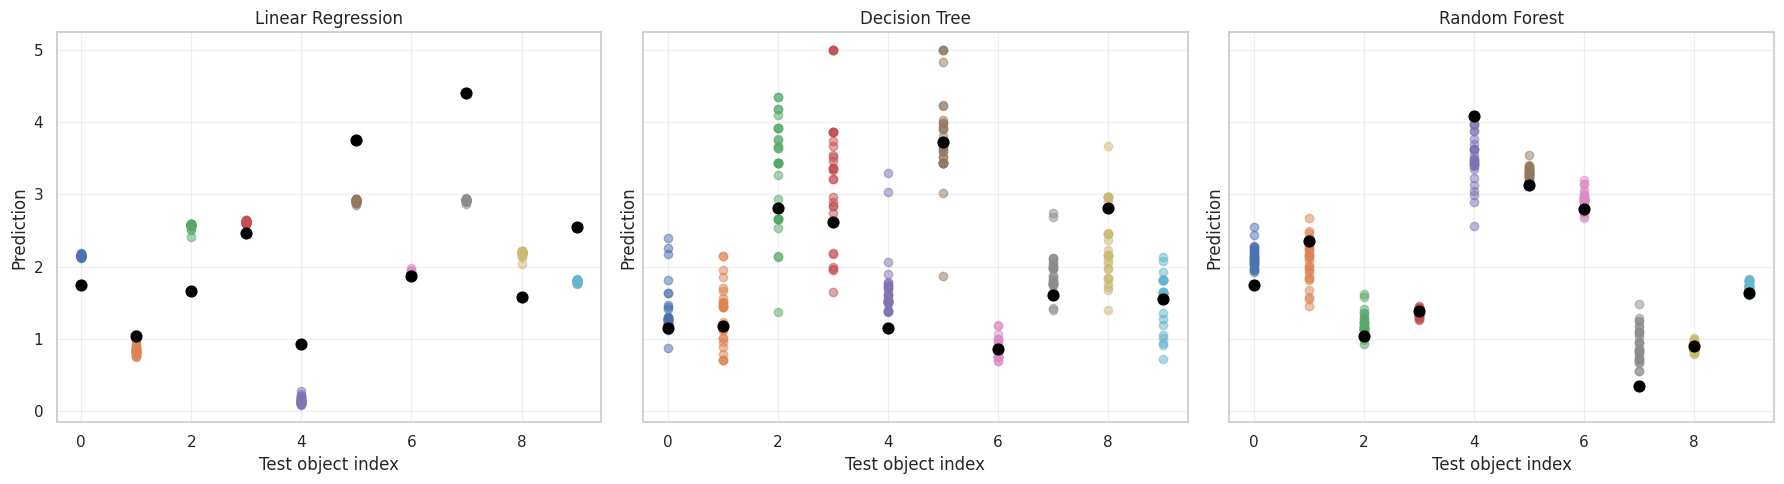

In [ ]:
models = [
    ("Linear Regression", LinearRegression()),
    ("Decision Tree", DecisionTreeRegressor(random_state=0)),
    ("Random Forest", RandomForestRegressor(
        n_estimators=10,
        max_depth=10,
        n_jobs=-1,
        random_state=0
    ))
]

num_runs = 30
num_test_objects = 10

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

all_preds = []

for ax, (name, model) in zip(axes, models):
    preds, y_test = plot_predictions(
        model, X, y,
        num_runs=num_runs,
        num_test_objects=num_test_objects,
        title=name,
        ax=ax
    )
    all_preds.append(preds)

plt.tight_layout()
plt.show()

**Ответ:** Linear Regression

Предсказания образуют узкие столбики: разброс очень маленький.
Однако средний уровень предсказаний для многих объектов заметно смещён относительно истинных значений (чёрных точек).
Это соответствует низкому variance и высокому bias: линейная модель слишком простая и недообучается.

Decision Tree

Столбики широкие: сильный разброс предсказаний между разными бутстрап-моделями.
Иногда предсказания попадают точно в истинное значение, но в среднем колебания велики.
 низкий bias, высокий variance: дерево подстраивается под структуру данных, но крайне нестабильно.

Random Forest

Столбики намного уже, чем у дерева: variance сильно снижен за счёт усреднения большого числа деревьев.
При этом средние предсказания обычно ближе к истинным значениям.
Это соответствует низкому bias и низкому variance — наиболее стабильный и точный алгоритм среди трёх.

